<a href="https://colab.research.google.com/github/ArthurRicartte/Fuzzy_Soccer_Score/blob/main/FuzzyFootballScore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Variáveis de Entrada (Antecedentes)

Cada variável conta com 3 termos linguísticos modelados por funções de pertinência triangulares (trimf) e trapezoidais (trapmf):

Participação em Gols (Gols + Assistências na partida)

- Universo: [0, 5] ações diretas.

- Conjuntos: baixa [0, 0, 1], moderada [0, 1, 2], alta [1, 3, 5, 5].

Precisão de Passes Certos (Aproveitamento em %)

- Universo: [0, 100]%.

- Conjuntos: baixa [0, 0, 50, 70], media [60, 75, 90], excelente [80, 90, 100, 100].

Desarmes (Interceptações e ações defensivas completadas)

- Universo: [0, 10] desarmes.

- Conjuntos: poucos [0, 0, 1, 3], razoaveis [2, 4, 6], muitos [5, 8, 10, 10].

Duelos Ganhos (Disputas físicas e aéreas ganhas)

- Universo: [0, 15] duelos.

- Conjuntos: poucos [0, 0, 2, 5], medios [4, 7, 10], muitos [8, 12, 15, 15].

Variável de Saída (Consequente)

Nota Sofascore Base

- Universo: [3.0, 10.0] (escala padrão de desempenho).

- Termos: ruim [3.0, 3.0, 6.6], boa [5.5, 6.6, 7.8], ótima [6.6, 10.0, 10.0].

Método de Defuzzificação: Centroide (Centro de Massa).

🟨 Pós-Processamento Híbrido (Cartões e Indisciplina)

Para manter a base de regras fuzzy focada nas estatísticas técnicas de jogo e evitar a explosão de combinações de regras, os cartões sofrem uma dedução direta pós-inferência:

🟨 Cartão Amarelo: -0.3 na nota final (penalização por advertência).

🟥 Cartão Vermelho: -1.5 na nota final (penalização severa por expulsão).

A nota final é limitada no intervalo rígido de 3.0 a 10.0.




In [2]:
# Instalando dependência para desenvolver o programa
!pip install -q scikit-fuzzy matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 17.4 MB/s eta 0:00:00


In [4]:
#Importando as dependências necessárias para rodar o programa:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

print("Bibliotecas instaladas tudo ok!")

Bibliotecas instaladas tudo ok!


            ⚽ Relatoório Fuzzy Soccer 🥅
👤 Jogador : Arrascaeta
🏁 Partida : Flamengo x ind. Del Valle
-------------------------------------------------------
📊 Estatísticas da Partida:
   • 🕒 Minutagem           : 31 minutos
   • ⚽Participação em Gols : 1
   • 📋Precisão de Passes   : 78%
   • 🔒Desarmes             : 1
   • 💪Duelos Ganhos        : 3
   • 🟨Cartões Amarelos     : 0
   • 🟥Cartões Vermelhos    : 0
-------------------------------------------------------
📈 Nota Base (Motor Fuzzy)  : 8.83
⛔ Penalização Cartões      : 0.00
⭐ NOTA SOFASCORE FINAL     : 8.83

Plotagem da vairável notas e seus conjuntos:



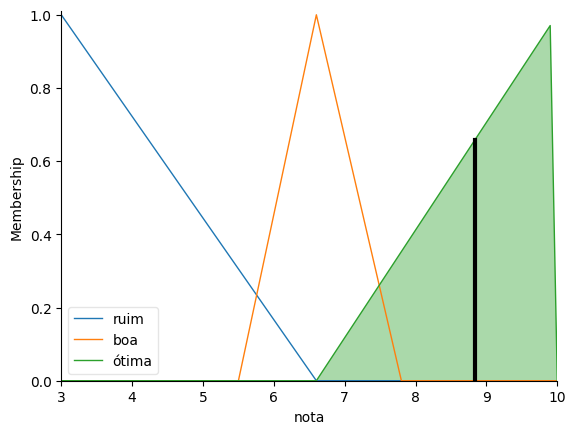

---------------------------------------------------------------------------

            ⚽ Relatoório Fuzzy Soccer 🥅
👤 Jogador : quintero
🏁 Partida : clt x deportivo de los hinchas
-------------------------------------------------------
📊 Estatísticas da Partida:
   • 🕒 Minutagem           : 69 minutos
   • ⚽Participação em Gols : 0
   • 📋Precisão de Passes   : 67%
   • 🔒Desarmes             : 6
   • 💪Duelos Ganhos        : 9
   • 🟨Cartões Amarelos     : 1
   • 🟥Cartões Vermelhos    : 0
-------------------------------------------------------
📈 Nota Base (Motor Fuzzy)  : 5.75
⛔ Penalização Cartões      : 0.30
⭐ NOTA SOFASCORE FINAL     : 5.45

Plotagem da vairável notas e seus conjuntos:



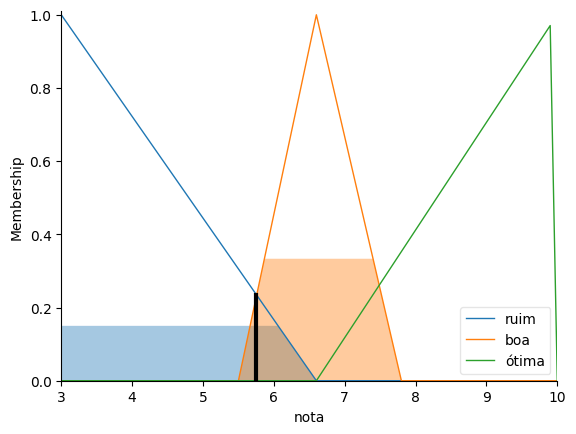

---------------------------------------------------------------------------



In [92]:
#Nos apps de nota de jogadores, existem penalizações para cartões amarelos e vermelhos:
PENALIZACAO_AMARELO = 0.3
PENALIZACAO_VERMELHO = 1.5

#Definindo os antecedentes:
participacao_gols = ctrl.Antecedent(np.arange(0, 6, 1), 'participacao_gols')          # 0 a 5 participações
passes = ctrl.Antecedent(np.arange(0, 101, 1), 'passes')     # 0 a 100% de precisão
desarmes = ctrl.Antecedent(np.arange(0, 11, 1), 'desarmes')   # 0 a 10 desarmes
duelos = ctrl.Antecedent(np.arange(0, 16, 1), 'duelos')     # 0 a 15 duelos ganhos

#Definindo o consequente (saída):
nota = ctrl.Consequent(np.arange(3, 10.1, 0.1), 'nota')       # 3 a 10 nota final

#Definindo os conjuntos de cada variável linguística:

# Participação em Gols (Gols + Assistências)
participacao_gols['baixa'] = fuzz.trimf(participacao_gols.universe, [0, 0, 1])
participacao_gols['moderada'] = fuzz.trimf(participacao_gols.universe, [0, 1, 2])
participacao_gols['alta'] = fuzz.trapmf(participacao_gols.universe, [1, 3, 5, 5])

# Precisão de Passes (%)
passes['baixa'] = fuzz.trapmf(passes.universe, [0, 0, 50, 70])
passes['media'] = fuzz.trimf(passes.universe, [60, 75, 90])
passes['excelente'] = fuzz.trapmf(passes.universe, [80, 90, 100, 100])

# Desarmes / Ações Defensivas
desarmes['poucos'] = fuzz.trapmf(desarmes.universe, [0, 0, 1, 3])
desarmes['razoaveis'] = fuzz.trimf(desarmes.universe, [2, 4, 6])
desarmes['muitos'] = fuzz.trapmf(desarmes.universe, [5, 8, 10, 10])

# Duelos Ganhos
duelos['poucos'] = fuzz.trapmf(duelos.universe, [0, 0, 2, 5])
duelos['medios'] = fuzz.trimf(duelos.universe, [4, 7, 10])
duelos['muitos'] = fuzz.trapmf(duelos.universe, [8, 12, 15, 15])

# Nota Sofascore Base (Pico estatístico calibrado em 6.6)
nota['ruim'] = fuzz.trimf(nota.universe, [3.0, 3.0, 6.6])
nota['boa'] = fuzz.trimf(nota.universe, [5.5, 6.6, 7.8])
nota['ótima'] = fuzz.trimf(nota.universe, [6.6, 10.0, 10.0])

# Regras fuzzy:

# Regras para enquadrar notas ruins:
#Use de participação em gols nessas 3 primeiras regras serve para evitar que um jogador que fez muitos gols ative elas
r1 = ctrl.Rule(participacao_gols['baixa'] & passes['baixa'], nota['ruim'])
r2 = ctrl.Rule(desarmes['poucos'] & duelos['poucos'] & participacao_gols['baixa'], nota['ruim'])
r3 = ctrl.Rule(passes['baixa'] & desarmes['poucos'] & participacao_gols['baixa'], nota['ruim'])

# Regras para nota mediana (foca em jogadores que não fizeram gols mas as outras estatísticas foram boas):
r4 = ctrl.Rule(participacao_gols['baixa'] & passes['media'] & (desarmes['razoaveis'] | duelos['medios']), nota['boa'])
r5 = ctrl.Rule(participacao_gols['baixa'] & passes['excelente'], nota['boa'])
r6 = ctrl.Rule(participacao_gols['baixa'] & (desarmes['muitos'] | duelos['muitos']), nota['boa'])

# Regras para as melhores notas:
r7 = ctrl.Rule(participacao_gols['moderada'] | participacao_gols['alta'], nota['ótima'])
r8 = ctrl.Rule(passes['excelente'] & desarmes['muitos'], nota['ótima'])

# Sistema de controle com as novas regras
sistema = ctrl.ControlSystem([r1, r2, r3, r4, r5, r6, r7, r8])
sim = ctrl.ControlSystemSimulation(sistema)

#Criando função para modularizar o código do input de dados
def avaliar_jogador(simulador, participacao_gols, passes, desarmes, duelos, cartoes_amarelos=0, cartoes_vermelhos=0, minutagem = 0, nome = "Não informado", partida = "Não informada"):
    # Atribuição dos antecedentes ao simulador
    simulador.input['participacao_gols'] = participacao_gols
    simulador.input['passes'] = passes
    simulador.input['desarmes'] = desarmes
    simulador.input['duelos'] = duelos

    # Execução da inferência fuzzy (Mamdani)
    simulador.compute()
    nota_base = simulador.output['nota']

    # Penalização por cartões
    tipo_expulsao = None
    penalizacao = 0
    if cartoes_amarelos >= 2:
      penalizacao = 1.5
      tipo_expulsao = "Segundo amarelo (vermelho indireto)"
    elif cartoes_vermelhos >= 1:
      penalizacao = 1.5
      tipo_expulsao = "Vermelho direto"
    elif cartoes_amarelos == 1:
      penalizacao = 0.3
    else:
      penalizacao = 0.0

  # Definindo a nota final (adicionando a penalização dos cartões)
    nota_final = max(3.0, min(10.0, nota_base - penalizacao))

  # Retorno deve ser um dicionário com todas as infos do jogador + os novos dados calculados
    return {
        'nome': nome,
        'partida': partida,
        'estatisticas': {
            'participacao_gols': participacao_gols,
            'passes': passes,
            'desarmes': desarmes,
            'duelos': duelos,
            'cartoes_amarelos': cartoes_amarelos,
            'cartoes_vermelhos': cartoes_vermelhos,
            'minutagem': minutagem,
            'tipo_expulsao': tipo_expulsao
        },
        'nota_base': nota_base,
        'penalizacao': penalizacao,
        'nota_final': nota_final
    }

#Função para exibir relatório do jogador:
def exibir_relatorio(resultado_avaliacao, consequente_nota=None, simulador=None, exibir_grafico=False):
  print("=" * 55)
  print(f"            ⚽ Relatoório Fuzzy Soccer 🥅")
  print("=" * 55)
  print(f"👤 Jogador : {resultado_avaliacao['nome']}")
  print(f"🏁 Partida : {resultado_avaliacao['partida']}")
  print("-" * 55)

  estatisticas = resultado_avaliacao['estatisticas']
  print("📊 Estatísticas da Partida:")
  print(f"   • 🕒 Minutagem           : {estatisticas['minutagem']} minutos")
  print(f"   • ⚽Participação em Gols : {estatisticas['participacao_gols']}")
  print(f"   • 📋Precisão de Passes   : {estatisticas['passes']}%")
  print(f"   • 🔒Desarmes             : {estatisticas['desarmes']}")
  print(f"   • 💪Duelos Ganhos        : {estatisticas['duelos']}")
  print(f"   • 🟨Cartões Amarelos     : {estatisticas['cartoes_amarelos']}")

  # Exibição inteligente dos cartões vermelhos / expulsão
  if estatisticas['tipo_expulsao']:
      print(f"   • 🟥Cartões Vermelhos    : {estatisticas['cartoes_vermelhos']} ({estatisticas['tipo_expulsao']})")
  else:
      print(f"   • 🟥Cartões Vermelhos    : {estatisticas['cartoes_vermelhos']}")

  print("-" * 55)
  print(f"📈 Nota Base (Motor Fuzzy)  : {resultado_avaliacao['nota_base']:.2f}")
  print(f"⛔ Penalização Cartões      : {resultado_avaliacao['penalizacao']:.2f}")
  print(f"⭐ NOTA SOFASCORE FINAL     : {resultado_avaliacao['nota_final']:.2f}")
  print("=" * 55 + "\n")

  # Exibição opcional do gráfico da defuzzificação
  if exibir_grafico and consequente_nota is not None and simulador is not None:
      print("Plotagem da vairável notas e seus conjuntos:\n")
      consequente_nota.view(sim=simulador)
      plt.show()
      print("-" * 75 + "\n")

# Adicionando testes:
jogador1 = avaliar_jogador(
    simulador=sim,
    nome = "Arrascaeta",
    partida = "Flamengo x ind. Del Valle",
    participacao_gols=1,
    passes=78,
    desarmes=1,
    duelos=3,
    cartoes_amarelos=0,
    cartoes_vermelhos=0,
    minutagem = 31
)

exibir_relatorio(jogador1, consequente_nota=nota, simulador=sim, exibir_grafico=True) #Assim que adiciona o teste já tem que executar (senão, ele repete o mesmo gráfico em todos)

jogador2 = avaliar_jogador(
    simulador=sim,
    nome = "quintero",
    partida = "clt x deportivo de los hinchas",
    participacao_gols=0,
    passes=67,
    desarmes=6,
    duelos=9,
    cartoes_amarelos=1,
    cartoes_vermelhos=0,
    minutagem = 69
)
exibir_relatorio(jogador2, consequente_nota=nota, simulador=sim, exibir_grafico=True)